<a href="https://colab.research.google.com/github/laistebas/classifica-o_credito/blob/main/Classifica%C3%A7%C3%A3o_de_Score_de_Cr%C3%A9dito_com_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Classificação de Score de Crédito com Machine Learning**

Este projeto visa automatizar a análise de concessão de crédito de uma instituição financeira. O objetivo é classificar clientes em três categorias (Bom, OK, Ruim) para otimizar o tempo de resposta e reduzir a inadimplência.

Tecnologias: Python, Pandas, Scikit-Learn, Seaborn.

# **Importação e Configurações**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

# Configuração visual dos gráficos
sns.set_theme(style="whitegrid")

# **Limpeza e Engenharia de Dados**

Nesta etapa, foi realizado o tratamento de variáveis categóricas para que o modelo matemático possa processá-las. Foi utilizado o LabelEncoder para transformar textos em números e remover colunas que não possuem poder preditivo (como IDs).

In [ ]:
# Carregando o dataset
df_clientes = pd.read_csv("clientes.csv")

# Remoção de identificadores irrelevantes para o modelo
df_clientes = df_clientes.drop(columns=["id_cliente"])

# Transformação de variáveis categóricas (texto) em numéricas
codificador = LabelEncoder()

for coluna in df_clientes.columns:
    # Codifica apenas colunas de texto, exceto o nosso alvo (score_credito)
    if df_clientes[coluna].dtype == "object" and coluna != "score_credito":
        df_clientes[coluna] = codificador.fit_transform(df_clientes[coluna])

display(df_clientes.head())

,mes,idade,profissao,salario_anual,num_contas,num_cartoes,juros_emprestimo,num_emprestimos,dias_atraso,num_pagamentos_atrasados,...,idade_historico_credito,investimento_mensal,comportamento_pagamento,saldo_final_mes,score_credito,emprestimo_carro,emprestimo_casa,emprestimo_pessoal,emprestimo_credito,emprestimo_estudantil
0,1,23.0,2,19114.12,3.0,4.0,3.0,4.0,3.0,7.0,...,265.0,21.46538,1,312.494089,Good,1,1,1,1,0
1,2,23.0,2,19114.12,3.0,4.0,3.0,4.0,3.0,4.0,...,266.0,21.46538,3,284.629162,Good,1,1,1,1,0
2,3,23.0,2,19114.12,3.0,4.0,3.0,4.0,3.0,7.0,...,267.0,21.46538,5,331.209863,Good,1,1,1,1,0
3,4,23.0,2,19114.12,3.0,4.0,3.0,4.0,5.0,4.0,...,268.0,21.46538,4,223.451310,Good,1,1,1,1,0
4,5,23.0,2,19114.12,3.0,4.0,3.0,4.0,6.0,4.0,...,269.0,21.46538,2,341.489231,Good,1,1,1,1,0


# **Divisão do Dataset e Escalonamento**

Para garantir uma avaliação justa, os dados foram divididos em dois conjuntos:


*   Treino (70%): Utilizado para o aprendizado dos modelos.

*   Teste (30%): Utilizado para verificar a precisão em dados que o modelo nunca viu.

Também foi aplicado o Feature Scaling (StandardScaler). Isso é fundamental para que variáveis com grandes magnitudes (como Renda Anual) não tenham um peso desproporcional sobre variáveis menores (como Número de Cartões).

In [ ]:
# Definição das variáveis explicativas (X) e do alvo (y)
X = df_clientes.drop(columns=["score_credito"])
y = df_clientes["score_credito"]

# Divisão entre treino e teste com semente aleatória para replicabilidade
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Escalonamento dos dados (Padronização)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **Treinamento e Comparação de Modelos**

Foi implentado dois modelos de classificação para comparação:

1.   Random Forest (Floresta Aleatória): Um conjunto de árvores de decisão que geralmente oferece alta precisão.

2.   KNN (K-Nearest Neighbors): Um modelo baseado na proximidade entre os pontos de dados.

In [ ]:
# Instanciando os algoritmos
modelo_rf = RandomForestClassifier(random_state=42)
modelo_knn = KNeighborsClassifier()

# Treinando os modelos com os dados escalonados
modelo_rf.fit(X_train_scaled, y_train)
modelo_knn.fit(X_train_scaled, y_train)

# Realizando previsões nos dados de teste
pred_rf = modelo_rf.predict(X_test_scaled)
pred_knn = modelo_knn.predict(X_test_scaled)

# Comparação simplificada por acurácia
print(f"Acurácia Random Forest: {accuracy_score(y_test, pred_rf):.2%}")
print(f"Acurácia KNN: {accuracy_score(y_test, pred_knn):.2%}")

Acurácia Random Forest: 82.44%
Acurácia KNN: 74.64%


# **Seleção do Modelo e Avaliação Detalhada**

Com uma acurácia de 82.44%, o Random Forest apresentou o melhor desempenho. Para validar sua eficácia, foi feita a análise do classification_report.

In [ ]:
from sklearn.metrics import classification_report

print("Relatório de Classificação Detalhado (Random Forest):")
print(classification_report(y_test, pred_rf))

Relatório de Classificação Detalhado (Random Forest):
              precision    recall  f1-score   support

        Good       0.80      0.78      0.79      5322
        Poor       0.81      0.85      0.83      8805
    Standard       0.84      0.83      0.83     15873

    accuracy                           0.82     30000
   macro avg       0.82      0.82      0.82     30000
weighted avg       0.82      0.82      0.82     30000



É crucial notar o Recall da classe Poor (0.85): isso significa que o modelo identifica corretamente 85% dos clientes de alto risco, o que é vital para a saúde financeira do banco.

# **Análise de Erros (Matriz de Confusão)**

A Matriz de Confusão nos permite visualizar onde ocorrem as classificações incorretas, ajudando a calibrar a tolerância ao risco do negócio.

<Figure size 800x600 with 0 Axes>

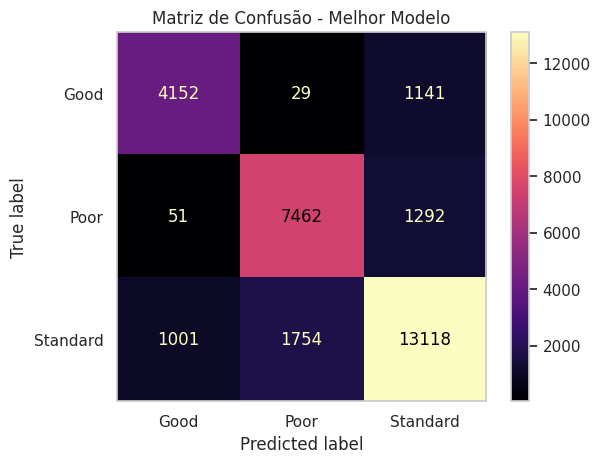

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, pred_rf)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo_rf.classes_)
disp.plot(cmap='magma', values_format='d')
plt.title('Matriz de Confusão - Melhor Modelo')
plt.grid(False)
plt.show()

Com base nos resultados:

*   Risco de Crédito (Poor): O modelo acertou 7.462 casos. O ponto mais positivo para o banco é que apenas 51 clientes "Ruins" foram classificados como "Bons" (falsos positivos perigosos). Isso demonstra um modelo conservador e seguro para a operação financeira.
*   Clientes Bons (Good): O modelo identificou corretamente 4.152 clientes. Houve uma confusão pequena com a classe "Standard" (1.141), o que é aceitável, já que a linha entre um cliente "OK" e "Bom" é tênue.
*   Volume de Acertos (Diagonal Principal): A linha diagonal (4152, 7462, 13118) concentra a grande maioria dos dados, o que confirma visualmente a acurácia de 82,4% que obtivemos anteriormente.






# **Importância das Variáveis (Feature Importance)**

Uma das maiores vantagens do Random Forest é a sua interpretabilidade. Abaixo, foi identificado quais atributos do cliente (ex: Renda, Mix de Crédito, Dívidas) tiveram maior peso na decisão do modelo. Essa informação é estratégica para o departamento de marketing e análise de risco do banco.

/tmp/ipython-input-2813120790.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importância', y='Atributo', data=df_importancia, palette='magma')


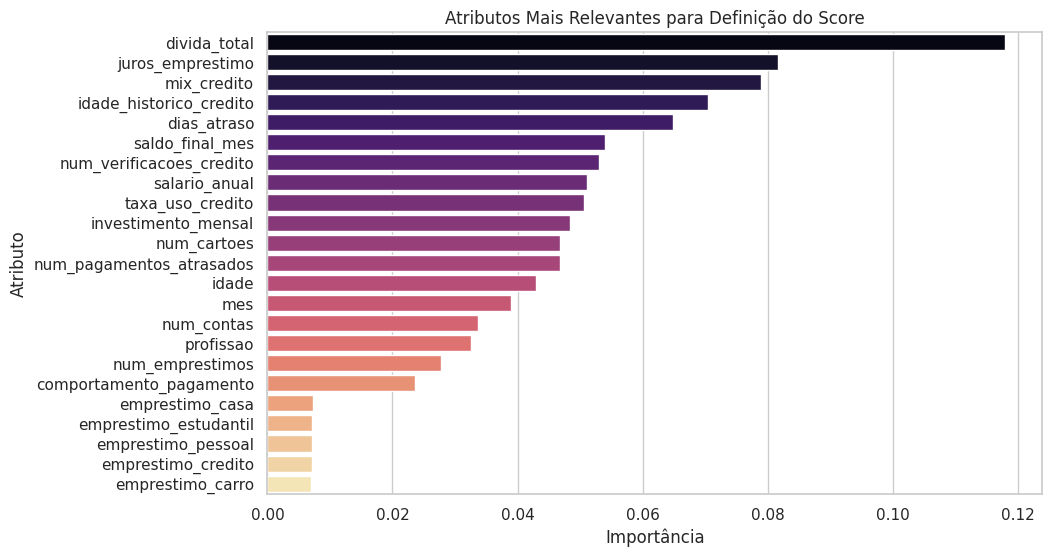

In [ ]:
# Extraindo a importância das colunas do modelo treinado
importancias = modelo_rf.feature_importances_
df_importancia = pd.DataFrame({'Atributo': X.columns, 'Importância': importancias})
df_importancia = df_importancia.sort_values(by='Importância', ascending=False)

# Visualização Gráfica
plt.figure(figsize=(10, 6))
sns.barplot(x='Importância', y='Atributo', data=df_importancia, palette='magma')
plt.title('Atributos Mais Relevantes para Definição do Score')
plt.show()

**O gráfico acima revela quais atributos mais impactam a definição do Score de Crédito.**

*   Dívida Total: É o fator de maior peso. Clientes com alto volume de dívidas acumuladas têm uma probabilidade drasticamente maior de serem classificados como "Poor".

*   Taxas de Juros e Mix de Crédito: O comportamento do cliente em relação aos produtos financeiros atuais é um preditor mais forte do que o próprio salário anual.

*   Variáveis de Baixo Impacto: Curiosamente, o tipo de profissão e o fato de possuir empréstimos específicos (como "estudantil" ou "pessoal") isoladamente têm pouca influência perto do histórico de atrasos e dívidas totais.

# **Conclusão Geral do Projeto**

**Resumo da Entrega:** O modelo baseado em **Random Forest** foi validado como a melhor solução para este problema, atingindo **82.44% de acurácia** global.

**Valor para o Negócio:**


1. Redução de Risco: A alta taxa de acerto na identificação de clientes "Poor" permite que o banco negue crédito a perfis insolventes com segurança.

2. Agilidade: O tempo de análise de um novo cliente é reduzido de dias (análise manual) para milissegundos.

3. Estratégia: O banco pode criar campanhas específicas para converter clientes "Standard" em "Good", focando na redução da dívida total, no qual foi visto ser o principal gargalo.
